# 🤖 Student Performance — Model Training

**Project:** Student Exam Score Prediction  
**Notebook:** Model Training & Evaluation  
**Author:** Shonesh Rawat  
**Date:** 2026

---
This notebook covers data preprocessing, model building, and evaluation for predicting
student average scores based on demographic and socio-economic features.

## 1. 📦 Import Libraries

We import all necessary libraries for preprocessing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. 📂 Load Dataset

We load the raw dataset — the same one used in EDA.

In [2]:
df = pd.read_csv('../data/raw/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. ⚙️ Data Preprocessing

Before building models, we need to:
- Create the target variable (`average_score`)
- Separate numeric and categorical features
- Apply One Hot Encoding to categorical features and Standard Scaling to numeric features using ColumnTransformer
- Split data into train and test sets

### 3.1 Create Target Variable
We create `average_score` — the mean of all three subject scores — as our regression target.

In [3]:
df['average_score'] = df[['reading_score','writing_score','math_score']].mean(axis=1).round(2)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


> 💡 `average_score` will serve as our single regression target, capturing overall academic performance.

### 3.2 Define Features and Target
Now we separate the dataset into input features (X) and the target variable (y).

In [4]:
X = df.drop(columns=['math_score', 'reading_score', 'writing_score', 'average_score'])
y = df['average_score']

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print()
print("Input Features:", X.columns.tolist())
print("Input Features:", list(X.columns))

Feature shape: (1000, 5)
Target shape : (1000,)

Input Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Input Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


> 💡 We drop the three individual score columns from X since `average_score` is derived from them — keeping them would cause **data leakage**.

### 3.3 Identify Numeric and Categorical Features
Before building the pipeline, we identify which columns are numeric and which are categorical.

In [5]:
num_features = X.select_dtypes(exclude='str').columns
cat_features = X.select_dtypes(include='str').columns

print(f"Numeric Features    : {len(num_features)} → {list(num_features)}")
print(f"Categorical Features: {len(cat_features)} → {list(cat_features)}")

Numeric Features    : 0 → []
Categorical Features: 5 → ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.4 Build Preprocessing Pipeline
We combine both transformations into a single ColumnTransformer pipeline.

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", cat_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

> 💡 ColumnTransformer applies different preprocessing steps to different columns in a single step — cleaner and more production-ready than doing them separately.

### 3.3 Train/Test Split
We split the data into 80% training and 20% testing.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)


Training set size: (800, 5)
Testing set size : (200, 5)


> 💡 We split **before** preprocessing to prevent data leakage — the preprocessor should only learn from training data, not the test set.

### 3.6 Apply Preprocessor
We fit the preprocessor on training data and transform both train and test sets.

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Transformed training shape:", X_train.shape)
print("Transformed testing shape :", X_test.shape)

Transformed training shape: (800, 17)
Transformed testing shape : (200, 17)


> 💡 `fit_transform` on training data — the preprocessor learns the encoding and scaling parameters only from training data. `transform` on test data — the same parameters are applied without re-learning.

## 4. 🏗️ Model Building

We train 10 regression models and compare their performance.
A helper function keeps our code clean and consistent across all models.

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    return {"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4), "R²": round(r2,4)}

> 💡 This helper function trains a model, makes predictions, and returns MAE, RMSE, and R².

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "SVR":SVR()
}

results = []
for name, model in models.items():
    result = evaluate_model(name,model,X_train, X_test, y_train, y_test)
    results.append(result)
results = pd.DataFrame(results).sort_values(by='R²',ascending=False).reset_index(drop=True)
results

,Model,MAE,RMSE,R²
0,Linear Regression,10.4903,13.4017,0.1622
1,Ridge,10.4931,13.4035,0.1619
2,SVR,10.7546,13.6913,0.1256
3,AdaBoost Regressor,10.8599,13.9108,0.0973
4,Lasso,11.0886,14.1339,0.0681
5,Random Forest Regressor,11.5037,14.8353,-0.0267
6,CatBoost Regressor,11.6342,14.9643,-0.0446
7,Decision Tree,11.7683,15.1185,-0.0662
8,XGBRegressor,11.7953,15.1630,-0.0725
9,K-Neighbors Regressor,12.3394,15.5701,-0.1309


> 💡 Models are sorted by R² — higher is better. RMSE and MAE are error metrics — lower is better.

### 5.2 R² Score Comparison

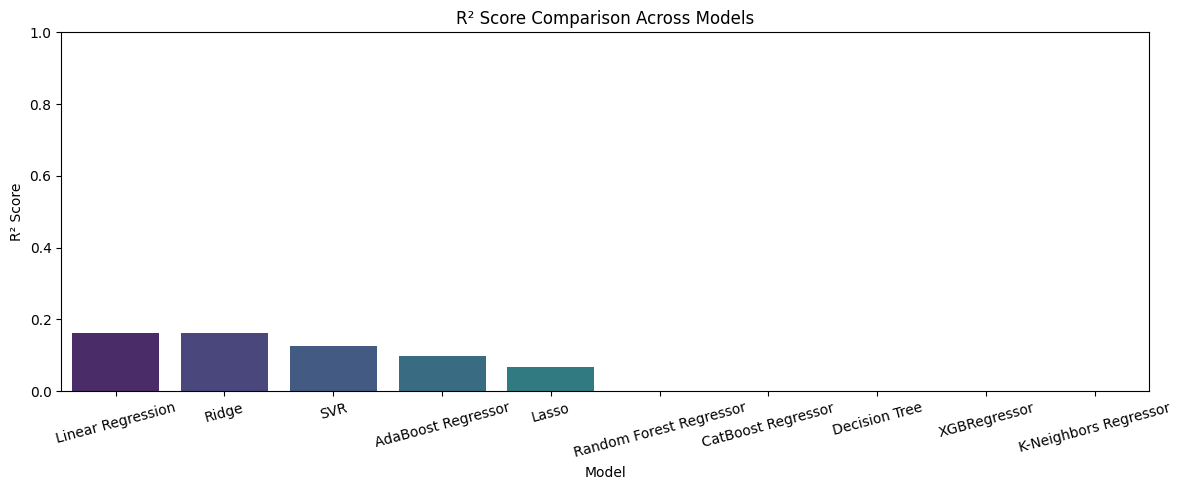

In [11]:
plt.figure(figsize=(12, 5))
sns.barplot(x='Model', y='R²', data=results, palette='viridis')
plt.title('R² Score Comparison Across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> 💡 R² closer to 1.0 means the model explains more variance in the target variable.

### 5.3 RMSE Comparison

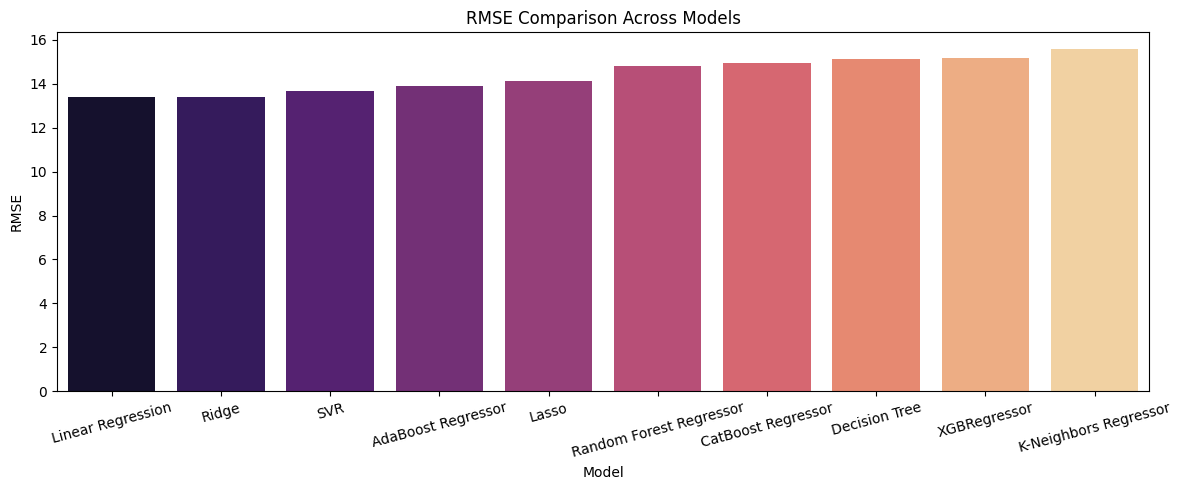

In [12]:
plt.figure(figsize=(12, 5))
sns.barplot(x='Model', y='RMSE', data=results, palette='magma')
plt.title('RMSE Comparison Across Models')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> 💡 Lower RMSE means the model's predictions are closer to the actual scores on average.

### 5.4 MAE Comparison

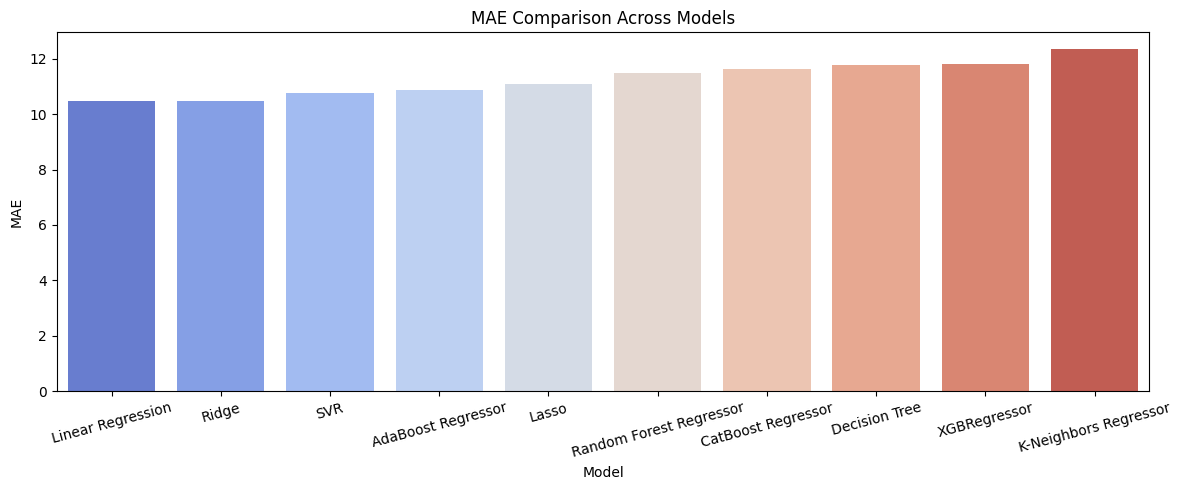

In [13]:
plt.figure(figsize=(12, 5))
sns.barplot(x='Model', y='MAE', data=results, palette='coolwarm')
plt.title('MAE Comparison Across Models')
plt.xticks(rotation=15 )
plt.tight_layout()
plt.show()

> 💡 MAE is easier to interpret than RMSE — it tells us the average error in the same units as the score (out of 100).

## 6. 🏆 Best Model & Conclusions

### 6.1 Best Performing Model

In [14]:
best = results.iloc[0]
print(f"Best Model : {best['Model']}")
print(f"R²         : {best['R²']}")
print(f"RMSE       : {best['RMSE']}")
print(f"MAE        : {best['MAE']}")

Best Model : Linear Regression
R²         : 0.1622
RMSE       : 13.4017
MAE        : 10.4903


### 6.2 Summary

| Metric | Meaning | Goal |
|---|---|---|
| **R²** | % of variance in scores explained by the model | Higher is better (max 1.0) |
| **RMSE** | Average prediction error in score units | Lower is better |
| **MAE** | Average absolute error in score units | Lower is better |

### Models Compared

| Model | Type |
|---|---|
| Linear Regression | Linear |
| Ridge | Linear + L2 Regularization |
| Lasso | Linear + L1 Regularization |
| KNN | Instance-based |
| SVR | Kernel-based |
| Decision Tree | Tree-based |
| Random Forest | Ensemble (Bagging) |
| AdaBoost | Ensemble (Boosting) |
| XGBoost | Ensemble (Gradient Boosting) |
| CatBoost | Ensemble (Gradient Boosting) |

### Next Steps 🚀
- **Hyperparameter Tuning:** Use `RandomizedSearchCV` on the best model to improve performance
- **Cross Validation:** Use k-fold cross validation for more robust evaluation
- **Feature Importance:** Analyze which features drive predictions the most
- **Deployment:** Save the best model using `pickle` or `joblib` for serving predictions
```